# 📊 Examen Final: Dataset de Kaggle + Análisis Financiero en Colab
Este notebook contiene las instrucciones para que desarrollar el examen final.

## ⭐ PASO 1 — Buscar un dataset en Kaggle
1. Entra a https://www.kaggle.com/datasets
2. Busca un dataset financiero (acciones, criptomonedas, oro, petróleo, etc.)
3. Descárgalo a tu computador (formato CSV).

## ⭐ PASO 2 — Subir el dataset a Colab

In [7]:
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive.zip


In [8]:
!unzip archive.zip

Archive:  archive.zip
  inflating: bitcoin_usd_gwa.csv     
  inflating: btccash_usd_gwa.csv     
  inflating: cardano_usd_gwa.csv     
  inflating: dash_usd_gwa.csv        
  inflating: ethereum_usd_gwa.csv    
  inflating: iota_usd_gwa.csv        
  inflating: litecoin_usd_gwa.csv    
  inflating: monero_usd_gwa.csv      
  inflating: nem_usd_gwa.csv         
  inflating: ripple_usd_gwa.csv      


In [9]:
import pandas as pd
df = pd.read_csv('bitcoin_usd_gwa.csv')
df.head(20)

,Unnamed: 0,Date,Open,High,Low,Close,Volume,VWAP,TWAP
0,1,2018-03-31,6877.060559,7224.073096,6845.765407,6980.794485,382634.619071,7044.705186,7044.127805
1,2,2018-03-30,7145.558812,7300.913155,6667.086968,6883.725208,609854.553605,6935.257228,6936.282983
2,3,2018-03-29,7983.837144,7996.389607,7005.998073,7154.143491,531839.173256,7535.636043,7574.005265
3,4,2018-03-28,7846.584324,8119.134881,7804.215096,7972.350959,275193.597624,7956.314335,7959.131977
4,5,2018-03-27,8189.532364,8244.970320,7806.926140,7856.948846,357522.246911,8007.858721,8009.491882
5,6,2018-03-26,8516.706685,8551.124088,7927.105266,8208.524302,380726.445854,8237.712795,8265.932570
6,7,2018-03-25,8601.548171,8694.805181,8455.456090,8521.301814,258690.568424,8584.686304,8584.752781
7,8,2018-03-24,8954.697522,9017.106690,8654.518307,8654.518307,299371.090008,8898.394347,8898.023195
8,9,2018-03-23,8770.403921,8901.222218,8359.147056,8901.222218,341786.786248,8574.942504,8578.105981
9,10,2018-03-22,8964.875668,9129.408760,8558.751570,8756.311082,345840.944988,8842.321903,8847.230044


## ⭐ PASO 3 — Limpieza y preparación del dataset
- Revisa tipos de datos
- Convierte fechas
- Ordena por fecha
- Maneja valores nulos

In [29]:
# TODO: escribir aquí tu proceso de limpieza
# --- LIMPIEZA DEL DATASET ---

# 1. Eliminar columnas que sobran
df = df.drop(columns=['Unnamed: 0'], errors='ignore')

# 2. Convertir la columna de fecha a tipo datetime
df['Date'] = pd.to_datetime(df['Date'])

# 3. Ordenar por fecha ascendente
df = df.sort_values('Date')

# 4. Manejo de valores nulos
df = df.dropna()

# 5. Reiniciar índices después de ordenar
df = df.reset_index(drop=True)

df.drop(columns=['daily_return'], inplace=True)

df.head(10)

,Date,Open,High,Low,Close,Volume,VWAP,TWAP
0,2015-01-03,314.036747,314.054547,283.234550,283.234550,550269.195356,301.560252,303.284471
1,2015-01-04,280.648594,284.226130,256.436014,262.204562,946120.852240,271.347063,272.535540
2,2015-01-05,262.111956,276.912533,262.111956,272.161003,706159.699523,270.419283,270.369332
3,2015-01-06,271.677882,283.796615,271.074652,282.981437,489564.369344,274.782407,275.026101
4,2015-01-07,282.780995,291.932839,280.298858,289.880512,537222.016257,284.604941,284.524936
5,2015-01-08,289.914634,289.914634,279.557161,280.337672,448498.486488,285.027587,284.921942
6,2015-01-09,280.254851,286.617579,278.110983,285.488514,423104.366531,281.693670,281.761235
7,2015-01-10,285.613438,286.245875,270.903975,271.606596,465651.442464,276.427513,276.759402
8,2015-01-11,271.490878,276.137069,262.147734,266.013027,400203.509536,270.651804,270.528483
9,2015-01-12,264.829510,272.030145,264.686054,268.492854,433326.981438,268.870644,268.821108


In [30]:
df.tail(10)

,Date,Open,High,Low,Close,Volume,VWAP,TWAP
1174,2018-03-22,8964.875668,9129.408760,8558.751570,8756.311082,345840.944988,8842.321903,8847.230044
1175,2018-03-23,8770.403921,8901.222218,8359.147056,8901.222218,341786.786248,8574.942504,8578.105981
1176,2018-03-24,8954.697522,9017.106690,8654.518307,8654.518307,299371.090008,8898.394347,8898.023195
1177,2018-03-25,8601.548171,8694.805181,8455.456090,8521.301814,258690.568424,8584.686304,8584.752781
1178,2018-03-26,8516.706685,8551.124088,7927.105266,8208.524302,380726.445854,8237.712795,8265.932570
1179,2018-03-27,8189.532364,8244.970320,7806.926140,7856.948846,357522.246911,8007.858721,8009.491882
1180,2018-03-28,7846.584324,8119.134881,7804.215096,7972.350959,275193.597624,7956.314335,7959.131977
1181,2018-03-29,7983.837144,7996.389607,7005.998073,7154.143491,531839.173256,7535.636043,7574.005265
1182,2018-03-30,7145.558812,7300.913155,6667.086968,6883.725208,609854.553605,6935.257228,6936.282983
1183,2018-03-31,6877.060559,7224.073096,6845.765407,6980.794485,382634.619071,7044.705186,7044.127805


## ⭐ PASO 4 — Análisis financiero básico
Calcula:
- Rendimiento diario
- Rendimiento promedio
- Volatilidad
- Máx y mín históricos

In [31]:
# TODO: calcular métricas financieras
# --- ANÁLISIS FINANCIERO BÁSICO ---

# Rendimiento diario (basado en el cierre)
df['daily_return'] = df['Close'].pct_change()

# Rendimiento promedio TOTAL del periodo completo
precio_inicial = df['Close'].iloc[0]
precio_final = df['Close'].iloc[-1]

rend_total = (precio_final - precio_inicial) / precio_inicial

# Volatilidad diaria
vol_diaria = df['daily_return'].std()

# Volatilidad anualizada
vol_anual = vol_diaria * (252**0.5)

# Máximos y mínimos históricos
max_price = df['Close'].max()
min_price = df['Close'].min()

print("📌 Resultados del análisis:")
print(f"• Rendimiento total del periodo: {rend_total:.6f}")
print(f"• Volatilidad diaria: {vol_diaria:.6f}")
print(f"• Volatilidad anualizada: {vol_anual:.6f}")
print(f"• Precio máximo histórico: {max_price}")
print(f"• Precio mínimo histórico: {min_price}")

# Mostrar los últimos valores limpios del df
df.tail()



📌 Resultados del análisis:
• Rendimiento total del periodo: 23.646691
• Volatilidad diaria: 0.042016
• Volatilidad anualizada: 0.666980
• Precio máximo histórico: 19587.37490631
• Precio mínimo histórico: 174.85629535


,Date,Open,High,Low,Close,Volume,VWAP,TWAP,daily_return
1179,2018-03-27,8189.532364,8244.970320,7806.926140,7856.948846,357522.246911,8007.858721,8009.491882,-0.042831
1180,2018-03-28,7846.584324,8119.134881,7804.215096,7972.350959,275193.597624,7956.314335,7959.131977,0.014688
1181,2018-03-29,7983.837144,7996.389607,7005.998073,7154.143491,531839.173256,7535.636043,7574.005265,-0.102631
1182,2018-03-30,7145.558812,7300.913155,6667.086968,6883.725208,609854.553605,6935.257228,6936.282983,-0.037799
1183,2018-03-31,6877.060559,7224.073096,6845.765407,6980.794485,382634.619071,7044.705186,7044.127805,0.014101


In [32]:
df.head()

,Date,Open,High,Low,Close,Volume,VWAP,TWAP,daily_return
0,2015-01-03,314.036747,314.054547,283.234550,283.234550,550269.195356,301.560252,303.284471,NaN
1,2015-01-04,280.648594,284.226130,256.436014,262.204562,946120.852240,271.347063,272.535540,-0.074249
2,2015-01-05,262.111956,276.912533,262.111956,272.161003,706159.699523,270.419283,270.369332,0.037972
3,2015-01-06,271.677882,283.796615,271.074652,282.981437,489564.369344,274.782407,275.026101,0.039757
4,2015-01-07,282.780995,291.932839,280.298858,289.880512,537222.016257,284.604941,284.524936,0.024380


## ⭐ PASO 5 — Gráficos obligatorios
- Serie de precios
- Rendimientos
- Volumen (si aplica)

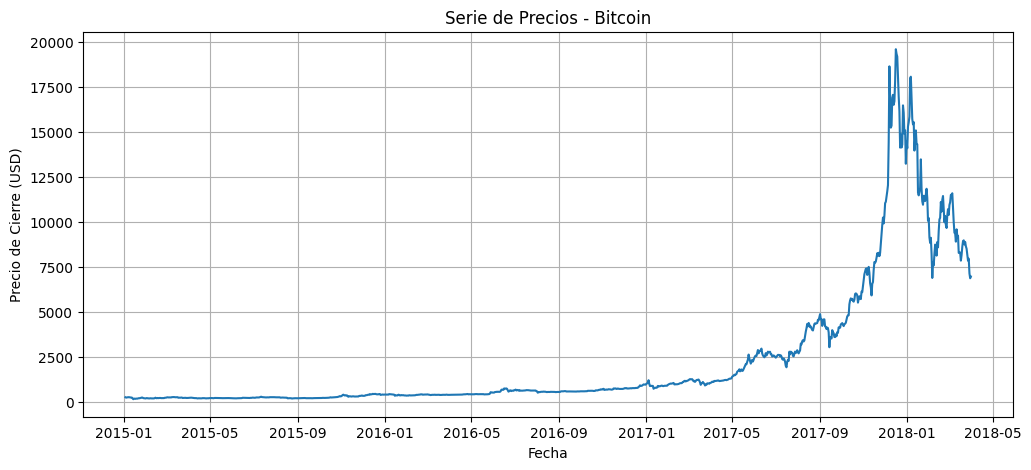

In [33]:
import matplotlib.pyplot as plt
# 1. Serie de precios (Close)
# ================================
plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['Close'])
plt.title('Serie de Precios - Bitcoin')
plt.xlabel('Fecha')
plt.ylabel('Precio de Cierre (USD)')
plt.grid(True)
plt.show()


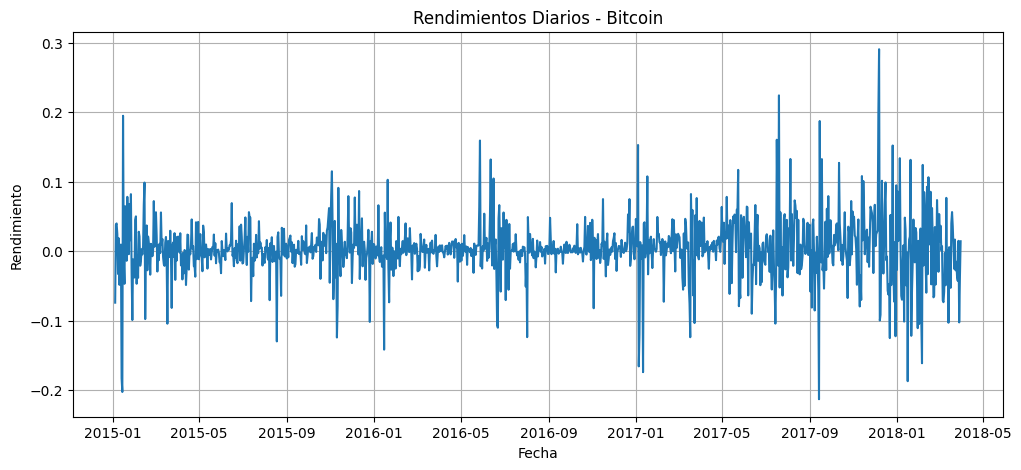

In [34]:
# 2. Rendimientos diarios
# ================================
plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['daily_return'])
plt.title('Rendimientos Diarios - Bitcoin')
plt.xlabel('Fecha')
plt.ylabel('Rendimiento')
plt.grid(True)
plt.show()

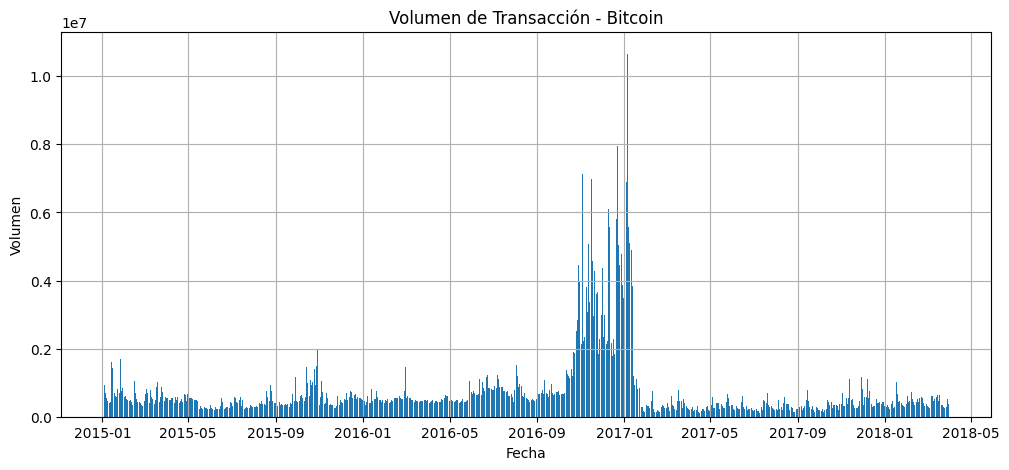

In [35]:
# 3. Volumen (si aplica)
# ================================
if 'Volume' in df.columns:
    plt.figure(figsize=(12,5))
    plt.bar(df['Date'], df['Volume'])
    plt.title('Volumen de Transacción - Bitcoin')
    plt.xlabel('Fecha')
    plt.ylabel('Volumen')
    plt.grid(True)
    plt.show()
else:
    print("El dataset no contiene columna de Volumen.")

## ⭐ PASO 6 — Preguntas de análisis
1. ¿El activo es volátil? ¿Por qué?
2. ¿Tiene tendencia clara?
3. ¿Hay eventos con movimientos fuertes?
4. ¿Es buena inversión a corto/largo plazo?
5. ¿Limitaciones del dataset?

Escribe tus respuestas abajo.

## ⭐ PASO 7 — Conclusiones
Redacta mínimo 5 conclusiones basadas en tu análisis.